# End - to - End ANN Project : Dry Bean Classification

# This project predicts the type of dry Bean Classification

# Problem Type

In [1]:

#Input:
#Area, perimeter, axis lengths, compactness, roundness and other shape measurements
#Output: 
#Bean class
# Machine-learning task: 
#Multiclass classification
# Model: 
#Artificial Neural Network
# Dataset size: 
#13,611 rows and 17 columns
#Target column: 
#Class
#Number of input features: 
#16

# Import the libraries

In [2]:
conda install openpyxl

Jupyter detected...
3 channel Terms of Service accepted
Channels:
 - defaults
Platform: win-64
Solving environment: done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder


from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Input
from tensorflow.keras.callbacks import EarlyStopping


import joblib
import warnings
warnings.filterwarnings("ignore")


In [4]:
df = pd.read_excel(r"C:\Users\saive\Downloads\dry+bean+dataset\DryBeanDataset\Dry_Bean_Dataset.xlsx")

In [5]:
df

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13606,42097,759.696,288.721612,185.944705,1.552728,0.765002,42508,231.515799,0.714574,0.990331,0.916603,0.801865,0.006858,0.001749,0.642988,0.998385,DERMASON
13607,42101,757.499,281.576392,190.713136,1.476439,0.735702,42494,231.526798,0.799943,0.990752,0.922015,0.822252,0.006688,0.001886,0.676099,0.998219,DERMASON
13608,42139,759.321,281.539928,191.187979,1.472582,0.734065,42569,231.631261,0.729932,0.989899,0.918424,0.822730,0.006681,0.001888,0.676884,0.996767,DERMASON
13609,42147,763.779,283.382636,190.275731,1.489326,0.741055,42667,231.653248,0.705389,0.987813,0.907906,0.817457,0.006724,0.001852,0.668237,0.995222,DERMASON


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

# Check the first Recoders

In [7]:
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


# Understand the dataset

In [8]:
print("Number of rows:",df.shape[0])
print("Number of columns:",df.shape[1])


Number of rows: 13611
Number of columns: 17


# Display all column anmes

In [9]:
print(df.columns.tolist())

['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4', 'Class']


# Check column data types

In [10]:
df.dtypes

Area                 int64
Perimeter          float64
MajorAxisLength    float64
MinorAxisLength    float64
AspectRation       float64
Eccentricity       float64
ConvexArea           int64
EquivDiameter      float64
Extent             float64
Solidity           float64
roundness          float64
Compactness        float64
ShapeFactor1       float64
ShapeFactor2       float64
ShapeFactor3       float64
ShapeFactor4       float64
Class               object
dtype: object

In [11]:
print("Statistical summary:", df.describe().T)

Statistical summary:                    count          mean           std           min  \
Area             13611.0  53048.284549  29324.095717  20420.000000   
Perimeter        13611.0    855.283459    214.289696    524.736000   
MajorAxisLength  13611.0    320.141867     85.694186    183.601165   
MinorAxisLength  13611.0    202.270714     44.970091    122.512653   
AspectRation     13611.0      1.583242      0.246678      1.024868   
Eccentricity     13611.0      0.750895      0.092002      0.218951   
ConvexArea       13611.0  53768.200206  29774.915817  20684.000000   
EquivDiameter    13611.0    253.064220     59.177120    161.243764   
Extent           13611.0      0.749733      0.049086      0.555315   
Solidity         13611.0      0.987143      0.004660      0.919246   
roundness        13611.0      0.873282      0.059520      0.489618   
Compactness      13611.0      0.799864      0.061713      0.640577   
ShapeFactor1     13611.0      0.006564      0.001128      0.002778   

# Data -Quality checking
## Check missing values

In [12]:
missing_values = df.isnull().sum()
print("missing_values")
print("\nTotal missing values:",missing_values.sum())

missing_values

Total missing values: 0


# Check duplited records

In [13]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:",duplicate_count)

Number of duplicate rows: 68


In [14]:
df = df.drop_duplicates().reset_index(drop=True)
print("Dataset shape after duplicate removal:",df.shape)

Dataset shape after duplicate removal: (13543, 17)


# Exploratory Data Analysis

EDA helps us understand:

Class distribution

Feature distributions
Outliers

Relationships between features

Correlations

Data imbalance

# Analyze the target classes

In [15]:
class_counts =df["Class"].value_counts()
print(class_counts)

Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1860
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


# Show percentages

In [16]:
class_percentages = (
    df["Class"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(class_percentages)

Class
DERMASON    26.18
SIRA        19.46
SEKER       14.97
HOROZ       13.73
CALI        12.04
BARBUNYA     9.76
BOMBAY       3.85
Name: proportion, dtype: float64


# Number of classses

In [17]:
print("Number of ben classes:",df["Class"].nunique())
print("Class names:",df["Class"].unique())

Number of ben classes: 7
Class names: ['SEKER' 'BARBUNYA' 'BOMBAY' 'CALI' 'HOROZ' 'SIRA' 'DERMASON']


# Plot class distribution

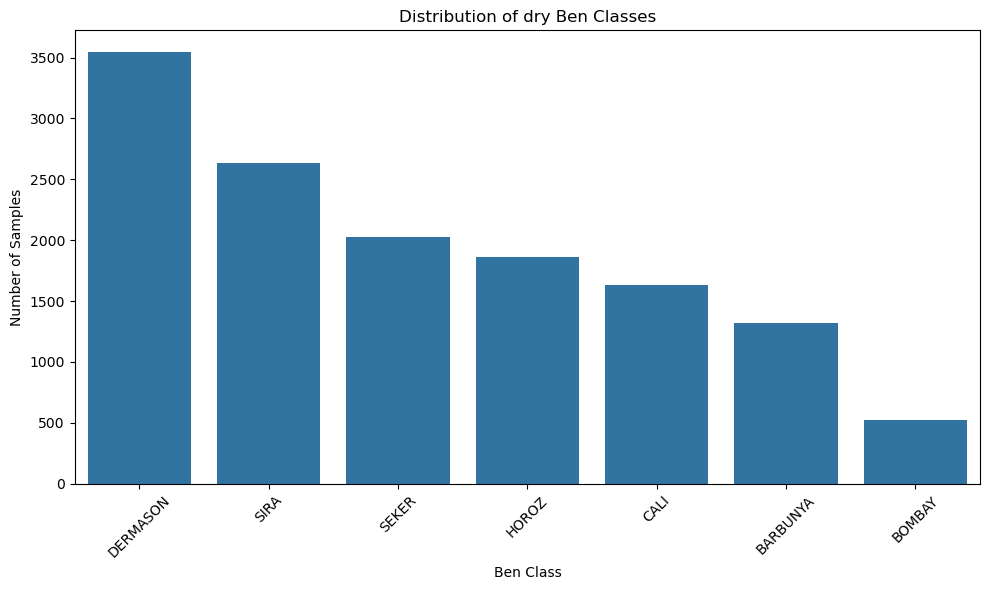

In [18]:
plt.figure(figsize=(10,6))

sns.countplot(
    data = df,
    x="Class",
    order=df["Class"].value_counts().index
)

plt.title("Distribution of dry Ben Classes")
plt.xlabel("Ben Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Interpretation

A taller bar means that the dataset contains more samples from that bean class.

The classes are not perfectly balanced. However, the imbalance is not extremely severe, so we can begin with a normal ANN and evaluate class-level precision and recall.

# Pie chart of target classes

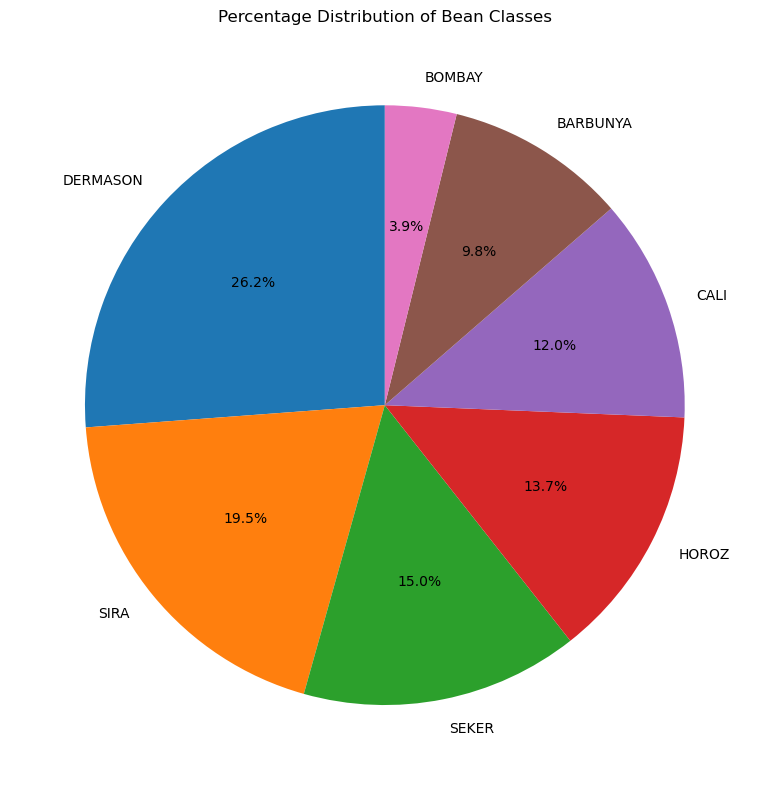

In [19]:
plt.figure(figsize=(8,8))

df["Class"].value_counts().plot(
    kind = "pie",
    autopct = "%1.1f%%",
    startangle  =90
)

plt.title("Percentage Distribution of Bean Classes")
plt.ylabel("")
plt.tight_layout()
plt.show()



# Separate Numerical columns

In [20]:
numerical_columns =df.select_dtypes(
    include = ["int64","float64"]
).columns

print("Number of numerical columns:",len(numerical_columns))
print(numerical_columns.tolist())

Number of numerical columns: 16
['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4']


# Histograms for all numerical features

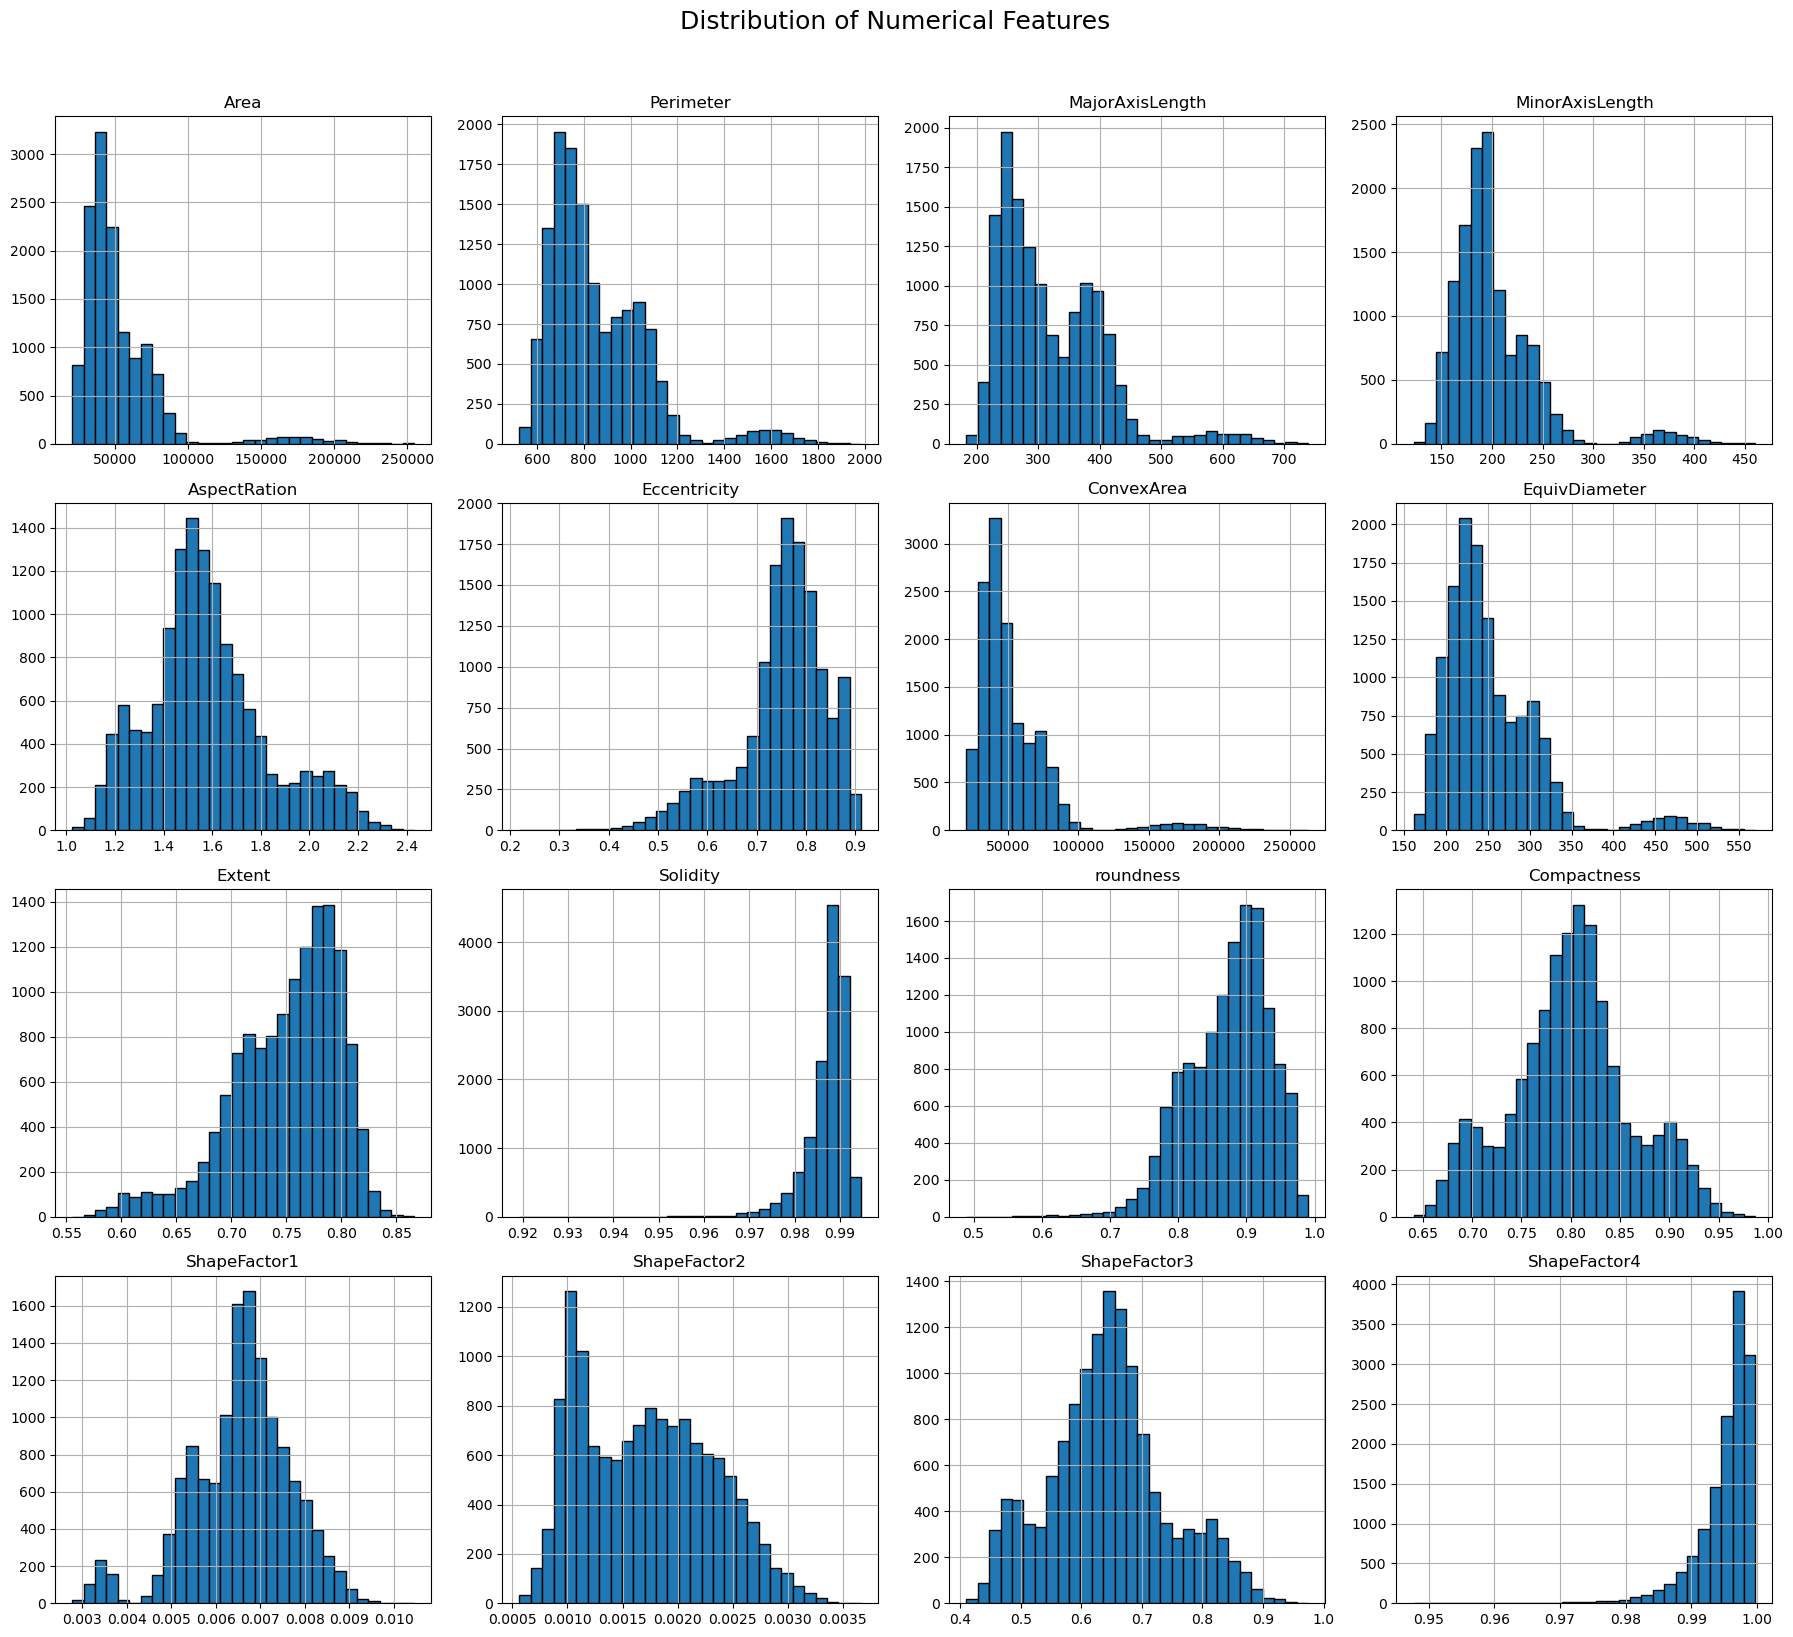

In [21]:
df[numerical_columns].hist(
    figsize=(18,16),
    bins=30,
    edgecolor = "black"
)

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize =18,
    y = 1.02

)

plt.tight_layout()
plt.show()

# How to interpret a histogram
A symmetric graph means that values are distributed evenly around the center.

A graph with a long right tail is positively skewed.

A graph with a long left tail is negatively skewed.

Separate peaks may indicate different bean groups.

# Check skewness

In [22]:
skewness=(
    df[numerical_columns]
    .skew()
    .sort_values(ascending=False)
)
print(skewness)

Area               2.947136
ConvexArea         2.936102
MinorAxisLength    2.232013
EquivDiameter      1.947303
Perimeter          1.628018
MajorAxisLength    1.365813
AspectRation       0.589045
ShapeFactor2       0.294332
ShapeFactor3       0.242767
Compactness        0.036309
ShapeFactor1      -0.530427
roundness         -0.648725
Extent            -0.895655
Eccentricity      -1.064932
Solidity          -2.546877
ShapeFactor4      -2.760125
dtype: float64


# Boxplot for outlier detection

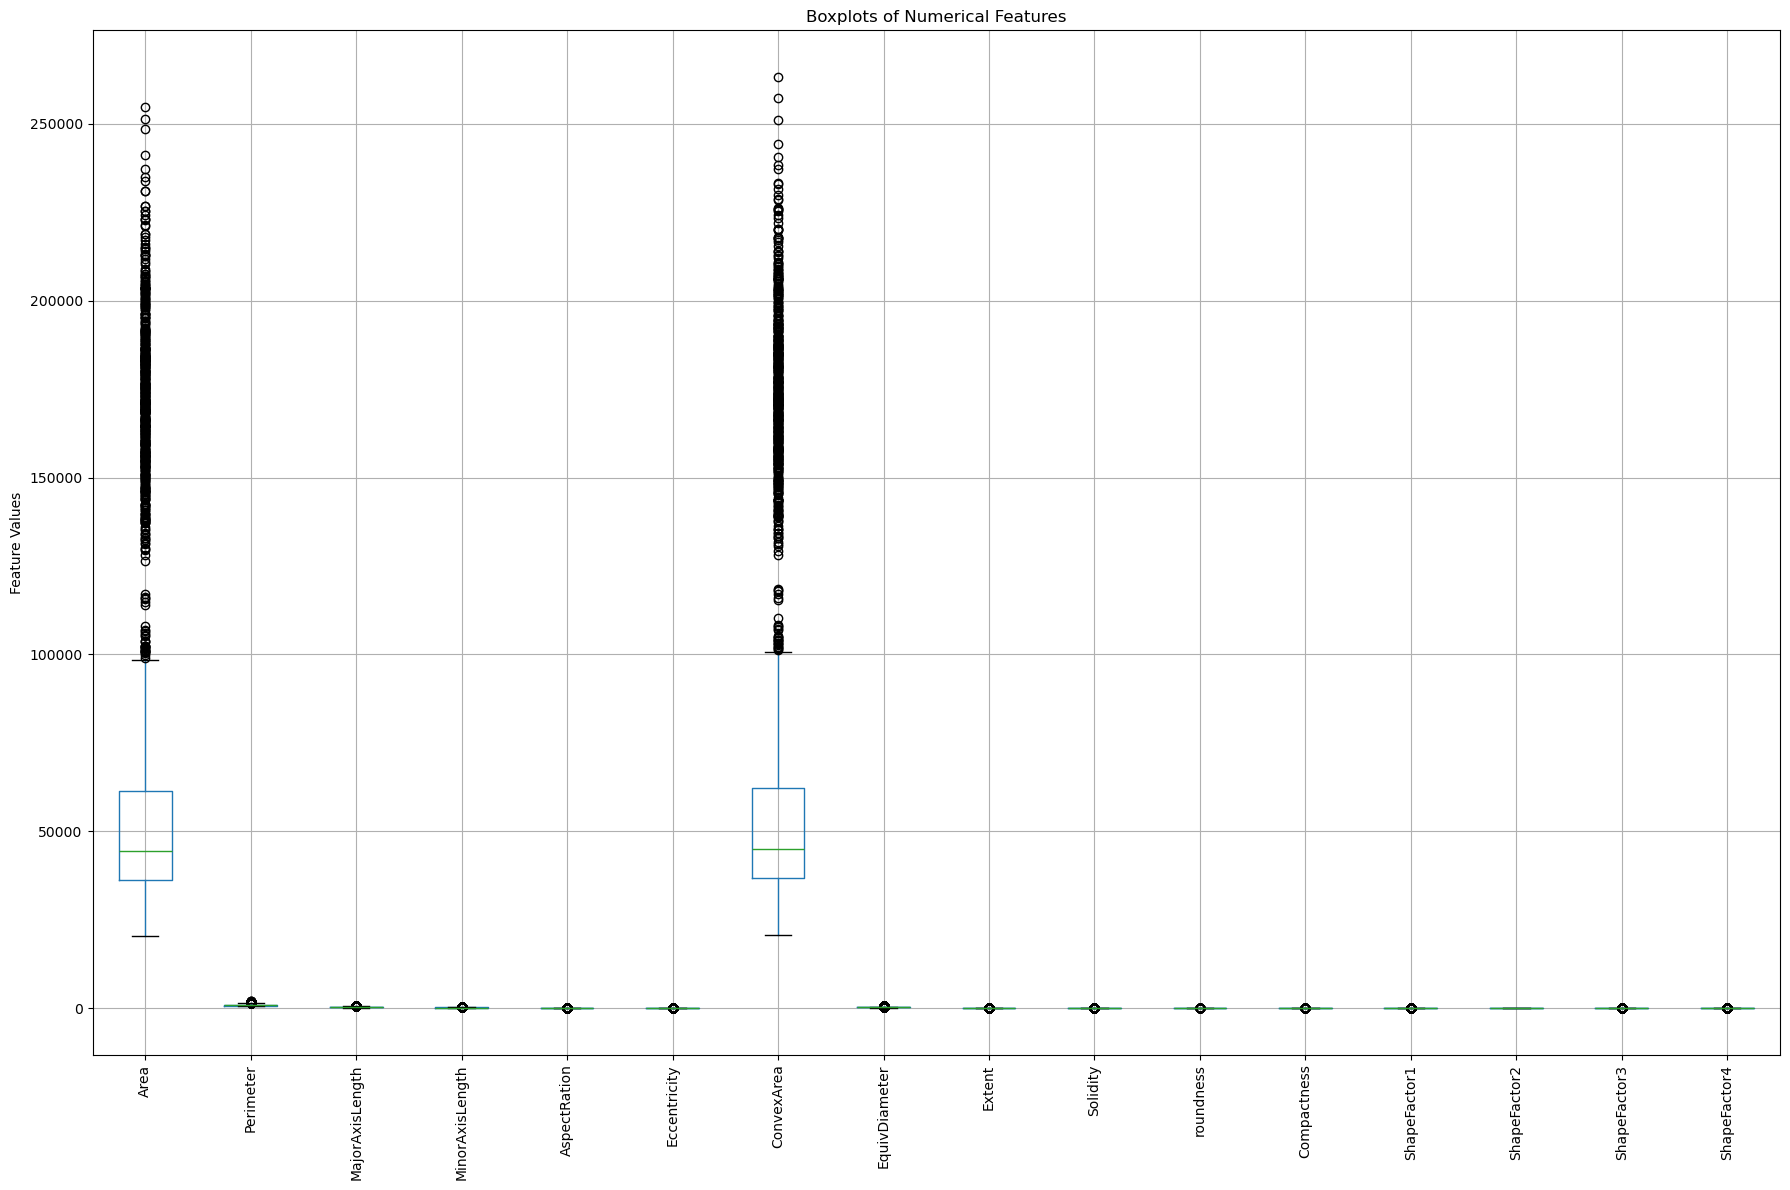

In [22]:
plt.figure(figsize=(18,12))
df[numerical_columns].boxplot(
    rot =90
)
plt.title("Boxplots of Numerical Features")
plt.ylabel("Feature Values")
plt.tight_layout()
plt.show()

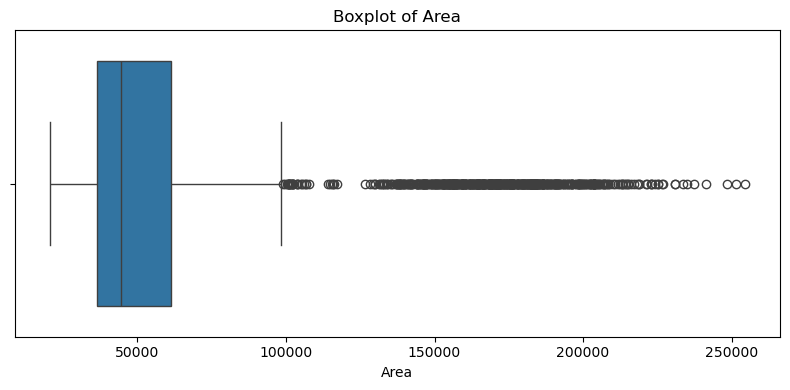

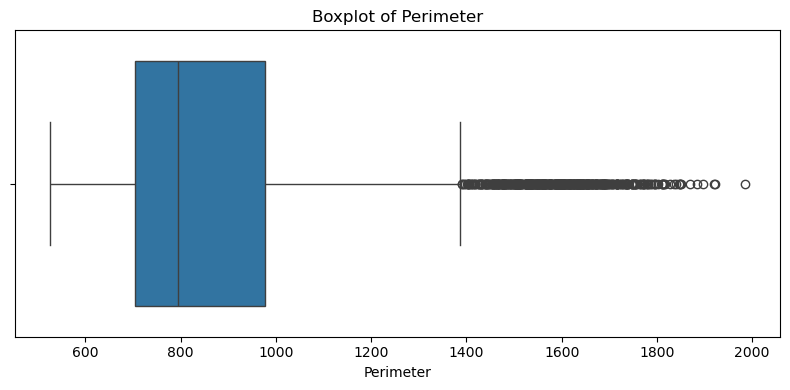

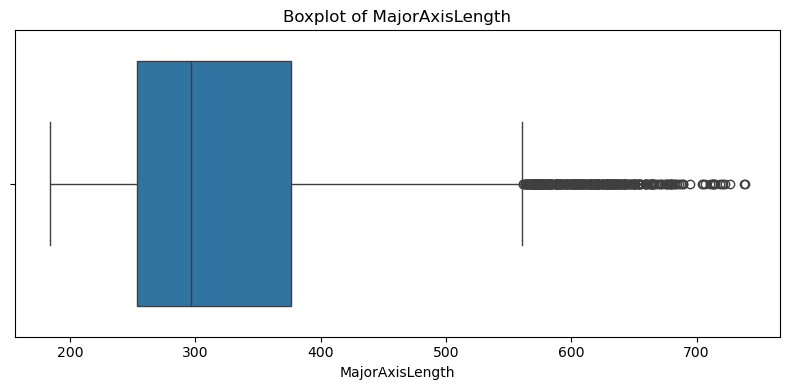

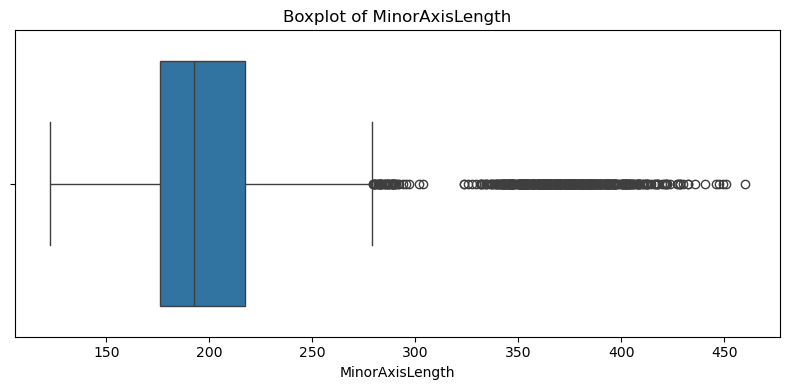

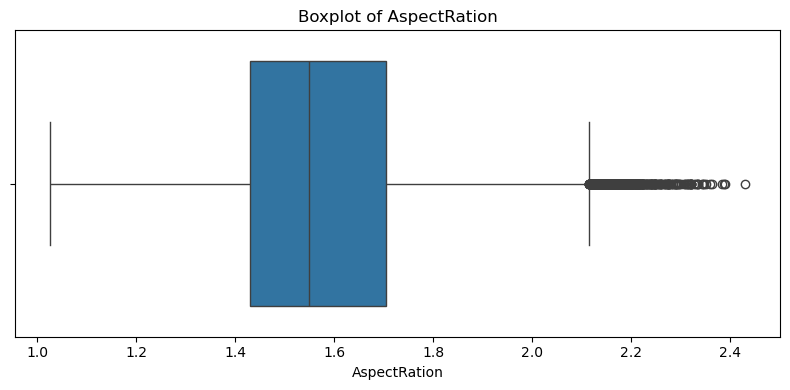

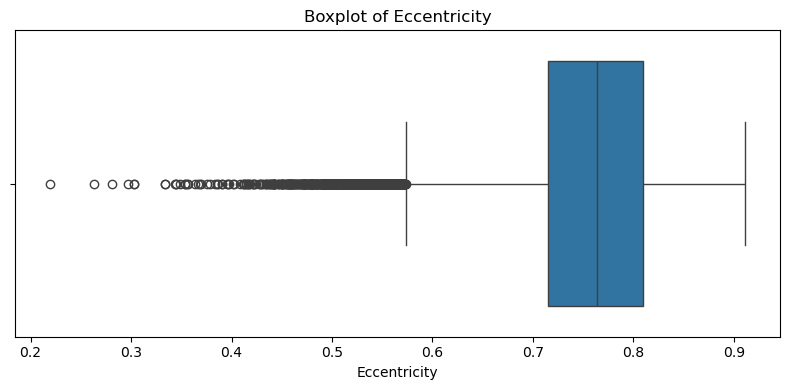

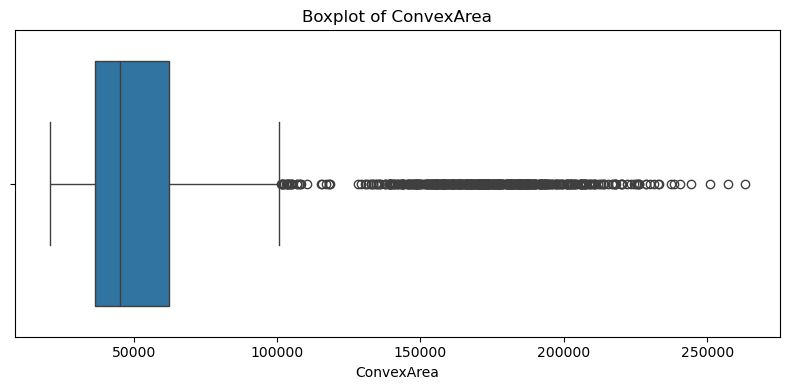

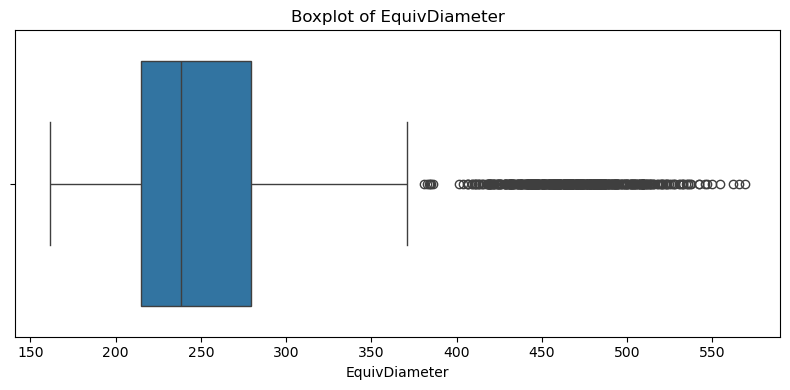

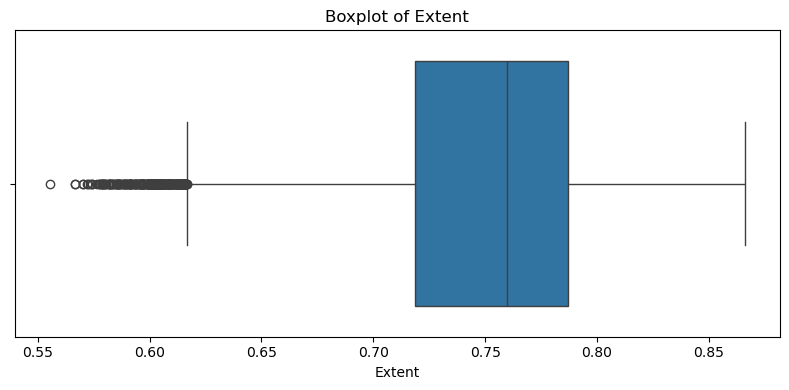

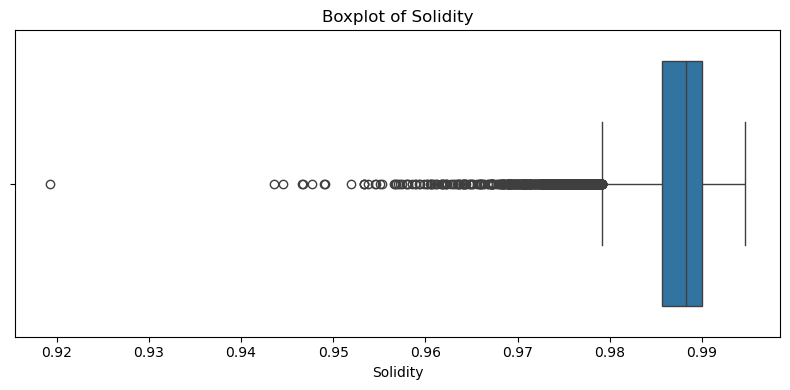

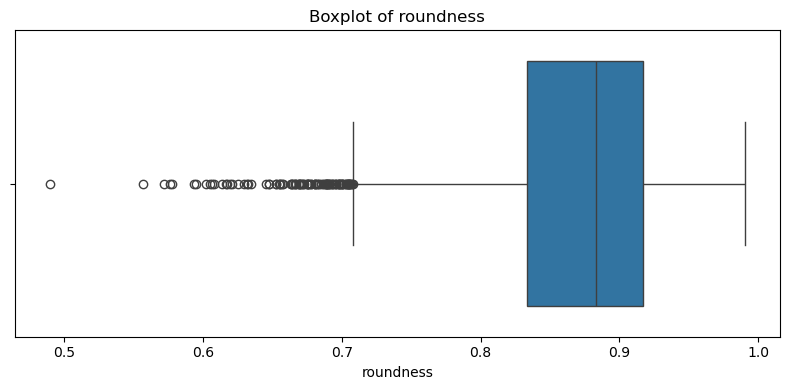

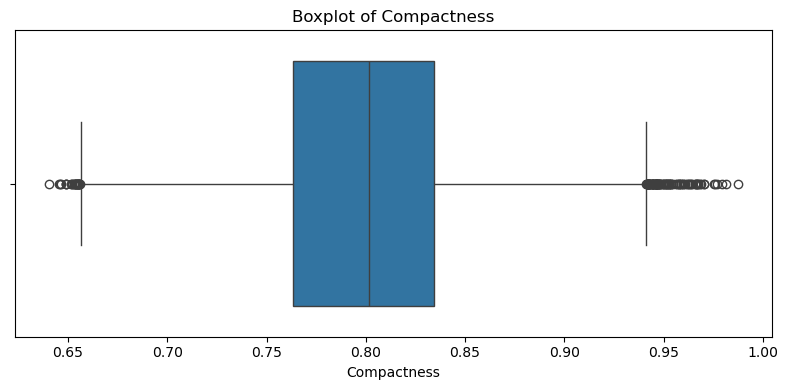

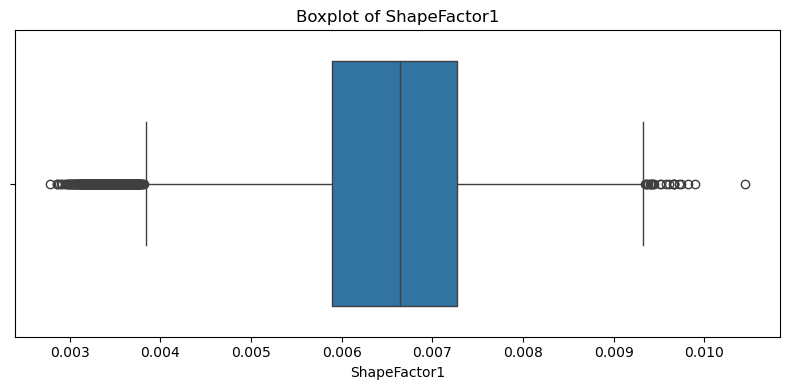

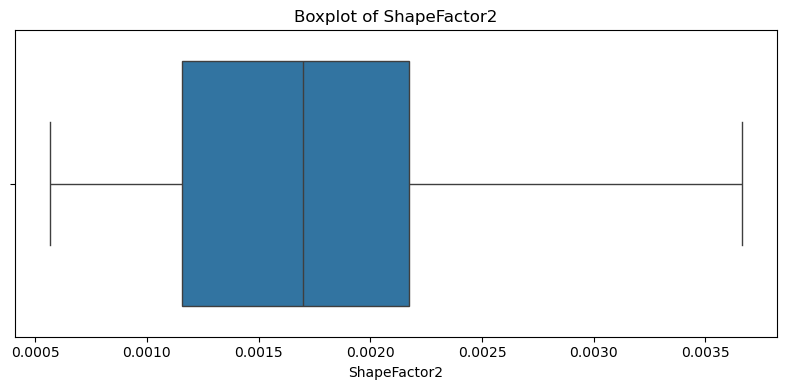

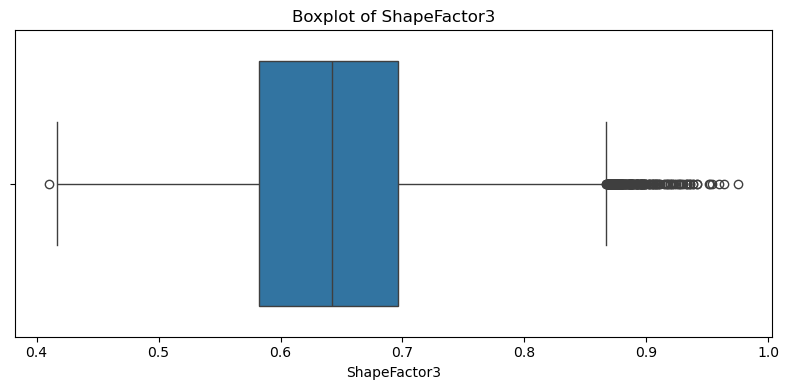

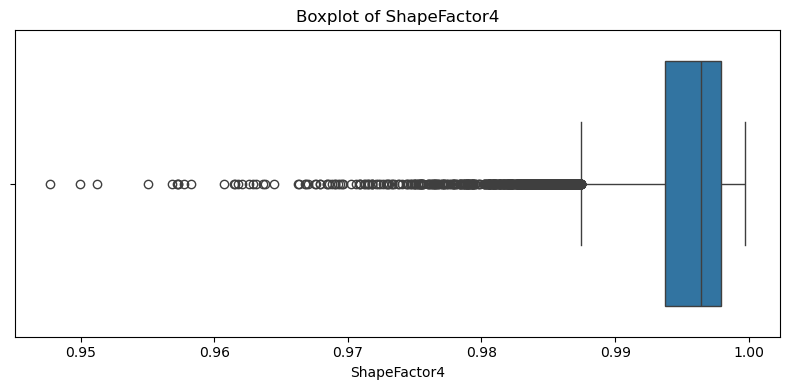

In [23]:
for column in numerical_columns:
    plt.figure(figsize=(8,4))

    sns.boxplot(
        x = df[column]
        
    )
    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    plt.tight_layout()
    plt.show()

# Correlation matrix

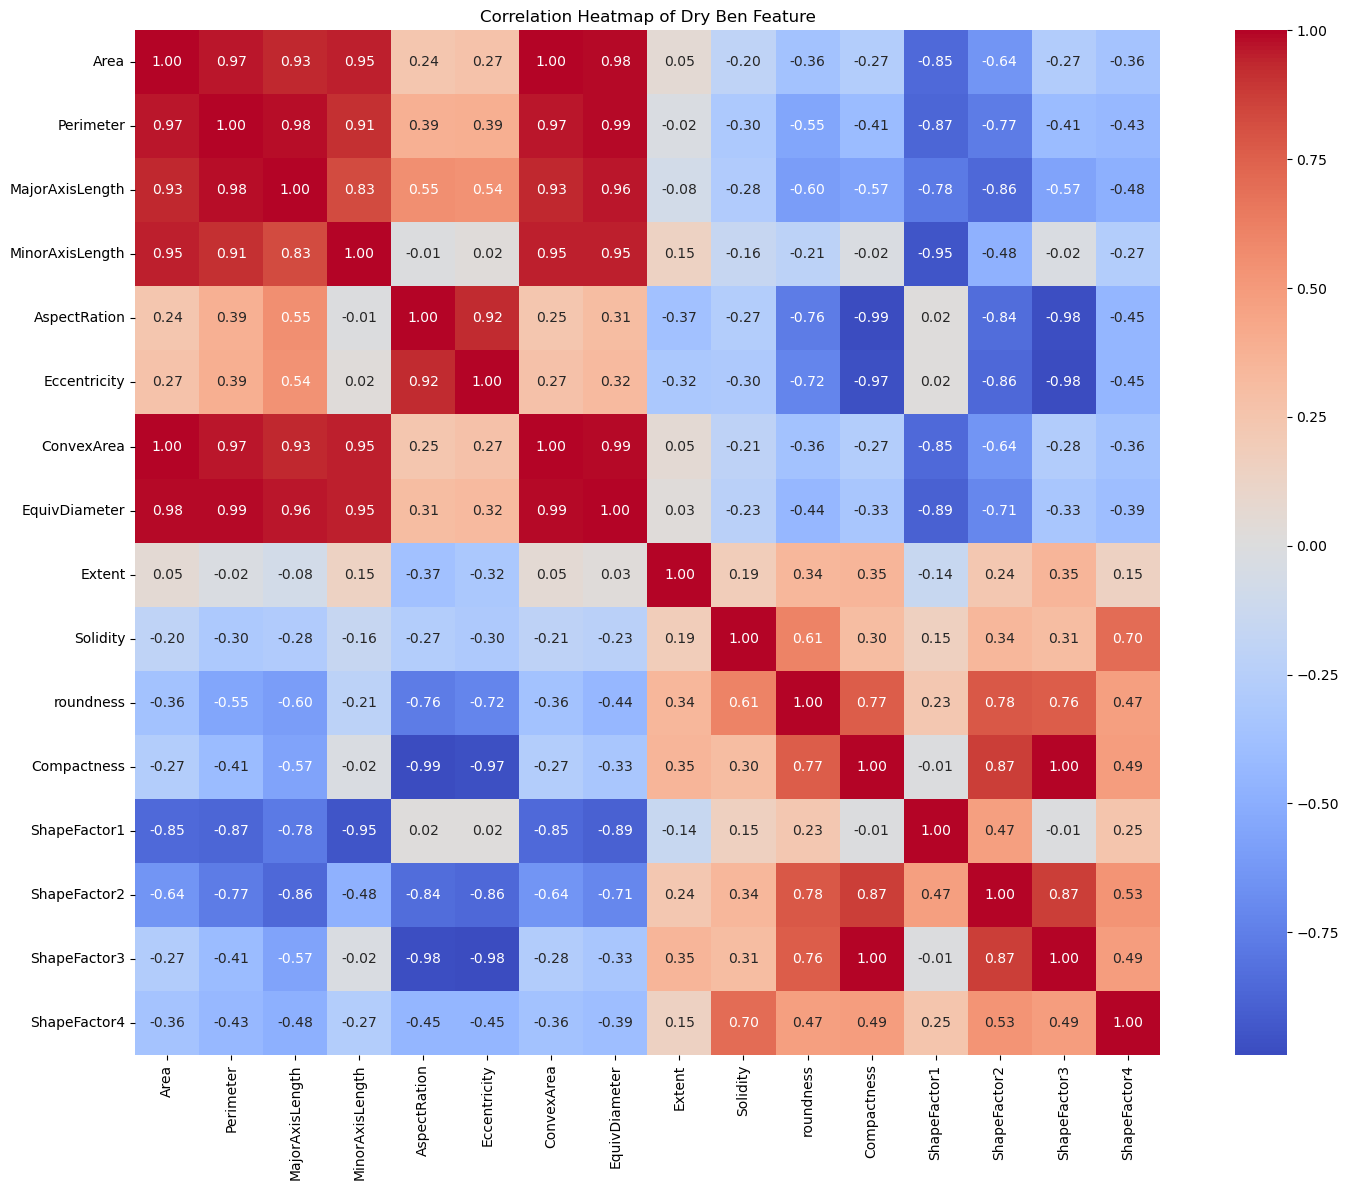

In [24]:
corr_matrix = df[numerical_columns].corr()
plt.figure(figsize=(16,12))
sns.heatmap(
    corr_matrix,
    annot =True,
    fmt =".2f",
    cmap = "coolwarm",
    square=True
)

plt.title("Correlation Heatmap of Dry Ben Feature")
plt.tight_layout()
plt.show()

# Compare important features by bean class
### Area by class

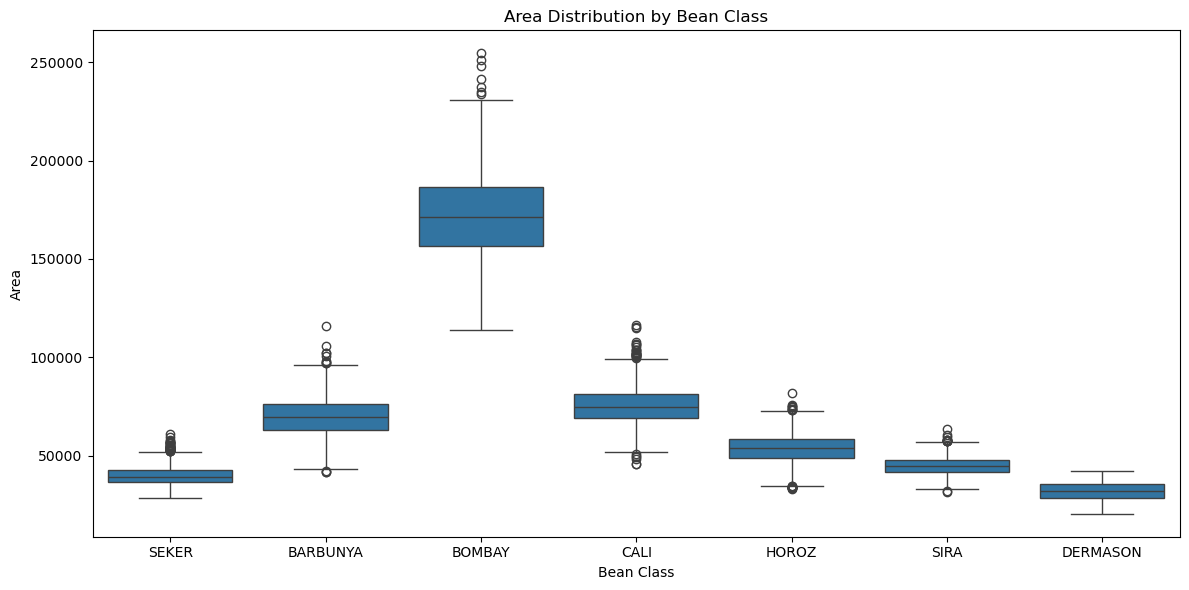

In [25]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data = df,
    x="Class",
    y="Area",
    
)

plt.title("Area Distribution by Bean Class")
plt.xlabel("Bean Class")
plt.ylabel("Area")
plt.tight_layout()
plt.show()

# Perimeter by class

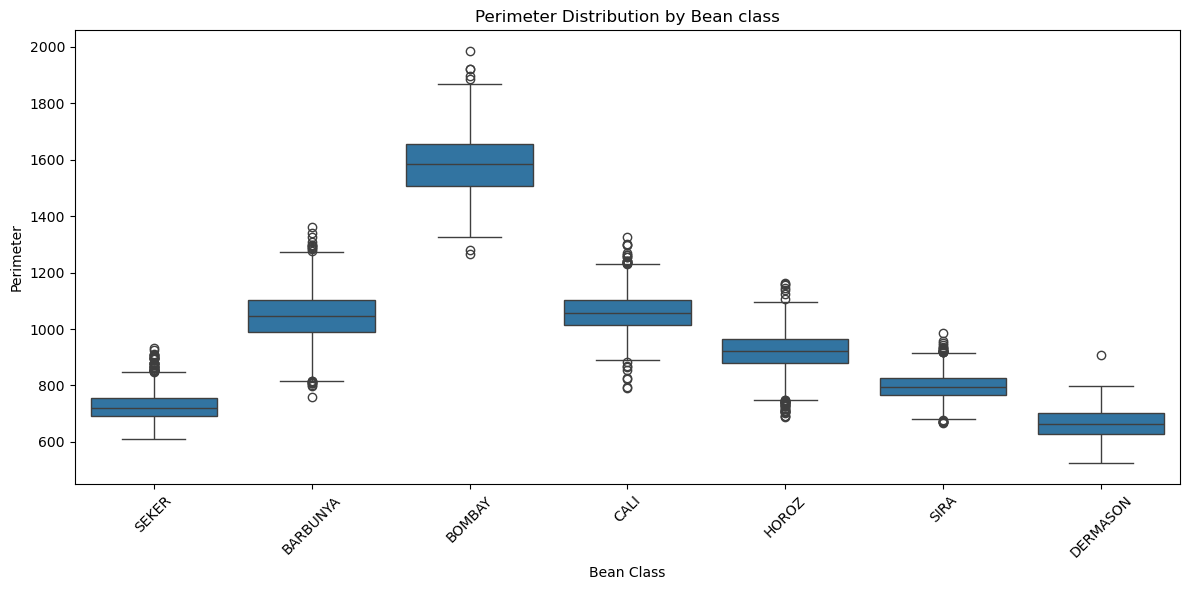

In [26]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data = df,
    x ="Class",
    y = "Perimeter"
)

plt.title("Perimeter Distribution by Bean class")
plt.xlabel("Bean Class")
plt.ylabel("Perimeter")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Compactness by class 
 


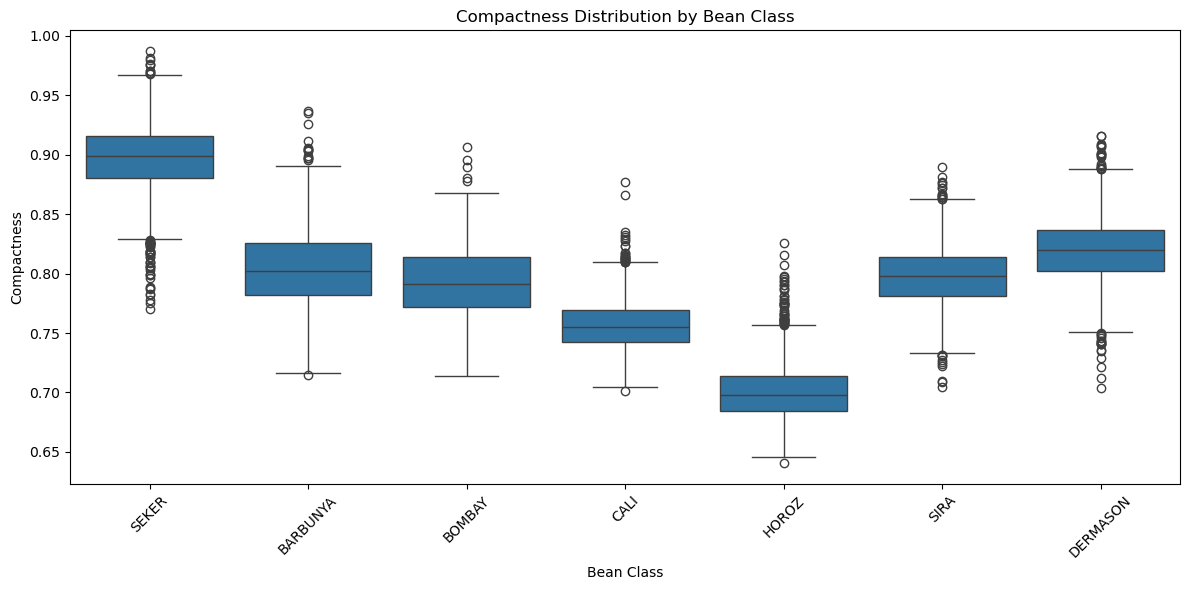

In [27]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data = df,
    x="Class",
    y ="Compactness"
)

plt.title("Compactness Distribution by Bean Class")
plt.xlabel("Bean Class")
plt.ylabel("Compactness")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Interpretation

These graphs help us determine whether different bean classes have visibly different physical properties.

When class distributions are separated, those features are useful for classification.

# Scatter plot

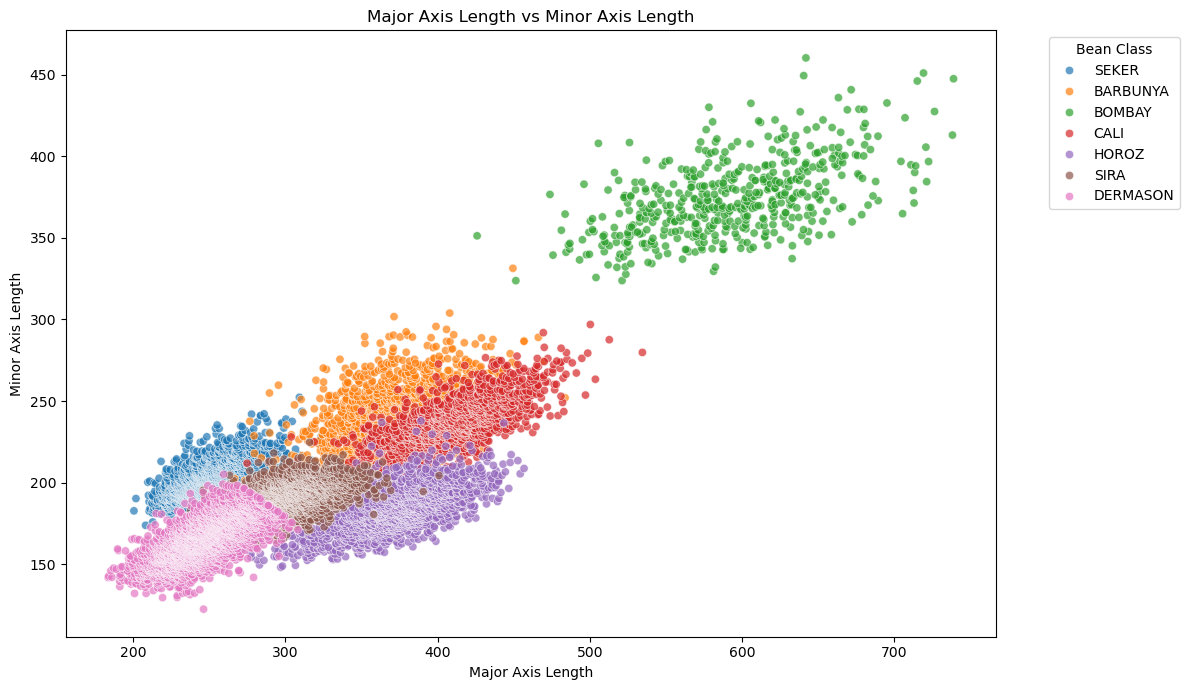

In [28]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df,
    x="MajorAxisLength",
    y="MinorAxisLength",
    hue="Class",
    alpha=0.7
)

plt.title("Major Axis Length vs Minor Axis Length")
plt.xlabel("Major Axis Length")
plt.ylabel("Minor Axis Length")
plt.legend(
    title="Bean Class",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# Explanation

Each point represents one bean.

The colour represents the bean class. If coloured groups form separate regions, these features can help the ANN distinguish between classes.

# Separate input features and target

In [29]:
X = df.drop("Class",axis =1)
y = df["Class"]

print("Feature shape:",X.shape)
print("Target ahspe:",y.shape)

Feature shape: (13543, 16)
Target ahspe: (13543,)


# Encoder the target labels

In [30]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [31]:
class_mapping = {
    class_name: encoded_value
    for encoded_value,class_name
    in enumerate(label_encoder.classes_)
}

print(class_mapping)

{'BARBUNYA': 0, 'BOMBAY': 1, 'CALI': 2, 'DERMASON': 3, 'HOROZ': 4, 'SEKER': 5, 'SIRA': 6}


In [32]:
print("Original labels:")
print(y.head())

Original labels:
0    SEKER
1    SEKER
2    SEKER
3    SEKER
4    SEKER
Name: Class, dtype: object


In [33]:
print("\nEcoder labels:")
print(y_encoded[:5])


Ecoder labels:
[5 5 5 5 5]


# Divide data into Training and Testing sets

In [34]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
    
)

print("X_train shape:",X_train.shape)
print("X_test shape:",X_test.shape)
print("y_train shape:",y_train.shape)
print("y_test shape:",y_test.shape)

X_train shape: (10834, 16)
X_test shape: (2709, 16)
y_train shape: (10834,)
y_test shape: (2709,)


# 80% of the data is used for training.
20% is used for final testing.
random_state=42 makes the split reproducible.
stratify=y_encoded maintains approximately the same class proportions in the training and testing sets.

The testing data should not be used during model training.

# Scale the input features

In [35]:
scaler = StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [36]:
print("Before scaling:")
print(X_train.iloc[0].values)

print("\nAfter scaling:")
print(X_train_scaled[0])

Before scaling:
[6.94710000e+04 1.06963800e+03 3.99100245e+02 2.25005782e+02
 1.77373329e+00 8.25923216e-01 7.10880000e+04 2.97410868e+02
 7.07386364e-01 9.77253545e-01 7.63026757e-01 7.45203420e-01
 5.74484671e-03 1.09284247e-03 5.55328138e-01 9.85004005e-01]

After scaling:
[ 0.56050943  1.00246171  0.92529132  0.50352511  0.78667132  0.82369553
  0.5822451   0.74988469 -0.87171546 -2.12216858 -1.87343212 -0.89813589
 -0.72427232 -1.05229433 -0.90313245 -2.30562201]


# StandardScaler formula
z=
σ
x−μ
	


Where:

x: Original value

μ: Mean of the feature

σ: Standard deviation

z: Standardized value

In [37]:
scaler.fit_transform(X_train)

array([[ 0.56050943,  1.00246171,  0.92529132, ..., -1.05229433,
        -0.90313245, -2.30562201],
       [ 1.01720246,  1.43581491,  0.84032368, ..., -0.57423887,
         0.43516216, -0.15632674],
       [ 0.40962972,  0.78736805,  1.1598124 , ..., -1.40447671,
        -1.75538346, -0.49513516],
       ...,
       [-0.50184861, -0.6019378 , -0.66005702, ...,  0.63677631,
         0.60033368,  0.9199932 ],
       [ 0.56180395,  0.89622506,  0.63047833, ..., -0.65355495,
        -0.11281708, -0.21917031],
       [-0.8394458 , -1.08947938, -0.99938397, ...,  0.82394201,
         0.14922239,  0.75992476]], shape=(10834, 16))

In [38]:
scaler.transform(X_test)

array([[-0.426017  , -0.5455207 , -0.83511728, ...,  1.55931041,
         1.95524578,  0.35618169],
       [-0.71973677, -0.90444997, -0.8092735 , ...,  0.5212499 ,
         0.03115292,  0.59648765],
       [-0.67827806, -0.85216392, -0.87564231, ...,  0.90371132,
         0.60212224,  0.21161597],
       ...,
       [-0.48614404, -0.69891458, -0.86614892, ...,  1.50531987,
         1.76229452,  0.7766014 ],
       [-0.01660802, -0.10992947, -0.27014131, ...,  0.49078046,
         1.17290234,  0.68253284],
       [-0.13400054, -0.13848771, -0.25053412, ...,  0.21625333,
         0.58652521,  0.54715844]], shape=(2709, 16))

# Step 11: Create a validation set

We will divide the training data again:

70% training

10% validation

20% testing

In [39]:
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_scaled,
    y_train,
    test_size=0.125,
    random_state=42,
    stratify=y_train
)

In [40]:
print("Final training shape:", X_train_final.shape)
print("Validation shape:", X_val.shape)
print("Testing shape:", X_test_scaled.shape)

Final training shape: (9479, 16)
Validation shape: (1355, 16)
Testing shape: (2709, 16)


# Purpose of each dataset
Training data: Updates model weights.

Validation data: Checks performance during training.
    
Testing data: Evaluates the final model on unseen data.

# Understand the ANN architecture

16 input features

        ↓
Dense layer: 64 neurons + ReLU

        ↓
        
Dropout: 20%

        ↓
        
Dense layer: 32 neurons + ReLU

        ↓
        
Dropout: 20%

        ↓
        
Dense layer: 16 neurons + ReLU

        ↓
        
Output layer: 7 neurons + Softmax

# Build the ANN model

In [41]:
number_of_features = X_train_final.shape[1]
number_of_classes = len(label_encoder.classes_)

print("Number of input features:", number_of_features)
print("Number of output classes:", number_of_classes)

Number of input features: 16
Number of output classes: 7


In [42]:
model = Sequential([
    Input(shape=(number_of_features,)),

    Dense(
        units=64,
        activation="relu"
    ),

    Dropout(rate=0.20),

    Dense(
        units=32,
        activation="relu"
    ),

    Dropout(rate=0.20),

    Dense(
        units=16,
        activation="relu"
    ),

    Dense(
        units=number_of_classes,
        activation="softmax"
    )
])

In [43]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           1,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 7)                   │             119 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,815 (14.90 KB)

 Trainable params: 3,815 (14.90 KB)

 Non-trainable params: 0 (0.00 B)

# Line-by-line ANN explanation

In [44]:
model = Sequential()

In [45]:
model

<Sequential name=sequential_1, built=False>

In [46]:
Dense(units=64, activation="relu")

<Dense name=dense_4, built=False>

In [47]:
Dropout(rate=0.20)

<Dropout name=dropout_2, built=True>

In [48]:
Dense(
    units=number_of_classes,
    activation="softmax"
)

<Dense name=dense_5, built=False>

# Compile the ANN model

In [49]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Adam updates the network weights using the calculated gradients.

It automatically adapts the learning rate for different parameters and usually performs well for structured classification problems.

# Create Early Stopping

In [50]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Explanation
monitor="val_loss": Watches validation loss.

patience=10: Stops when validation loss does not improve for ten consecutive epochs.

restore_best_weights=True: Returns the model to its best-performing weights.

verbose=1: Displays when training is stopped.

Early stopping reduces unnecessary training and overfitting.

# Train the ANN

In [51]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [52]:
print("X_train_final shape:", X_train_final.shape)
print("y_train_final shape:", y_train_final.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

X_train_final shape: (9479, 16)
y_train_final shape: (9479,)
X_val shape: (1355, 16)
y_val shape: (1355,)


In [53]:
number_of_features = X_train_final.shape[1]
number_of_classes = len(label_encoder.classes_)

model = Sequential([
    Input(shape=(number_of_features,)),

    Dense(
        units=64,
        activation="relu"
    ),

    Dropout(0.20),

    Dense(
        units=32,
        activation="relu"
    ),

    Dropout(0.20),

    Dense(
        units=16,
        activation="relu"
    ),

    Dense(
        units=number_of_classes,
        activation="softmax"
    )
])

In [54]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 64)                  │           1,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 7)                   │             119 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,815 (14.90 KB)

 Trainable params: 3,815 (14.90 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [56]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

In [57]:
history = model.fit(
    X_train_final,
    y_train_final,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
297/297 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7275 - loss: 0.7854 - val_accuracy: 0.9092 - val_loss: 0.2867
Epoch 2/100
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8826 - loss: 0.3456 - val_accuracy: 0.9321 - val_loss: 0.2044
Epoch 3/100
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8940 - loss: 0.3110 - val_accuracy: 0.9387 - val_loss: 0.1878
Epoch 4/100
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9042 - loss: 0.2743 - val_accuracy: 0.9402 - val_loss: 0.1837
Epoch 5/100
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9097 - loss: 0.2633 - val_accuracy: 0.9387 - val_loss: 0.1774
Epoch 6/100
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9119 - loss: 0.2577 - val_accuracy: 0.9395 - val_loss: 0.1709
Epoch 7/100
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9114 - loss: 0.2526 - val_accuracy: 0.9432 - val_loss: 0.1723
Epoch 8/100
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9134 - loss: 0.2455 - val_accu

# Plot training and validation accuracy

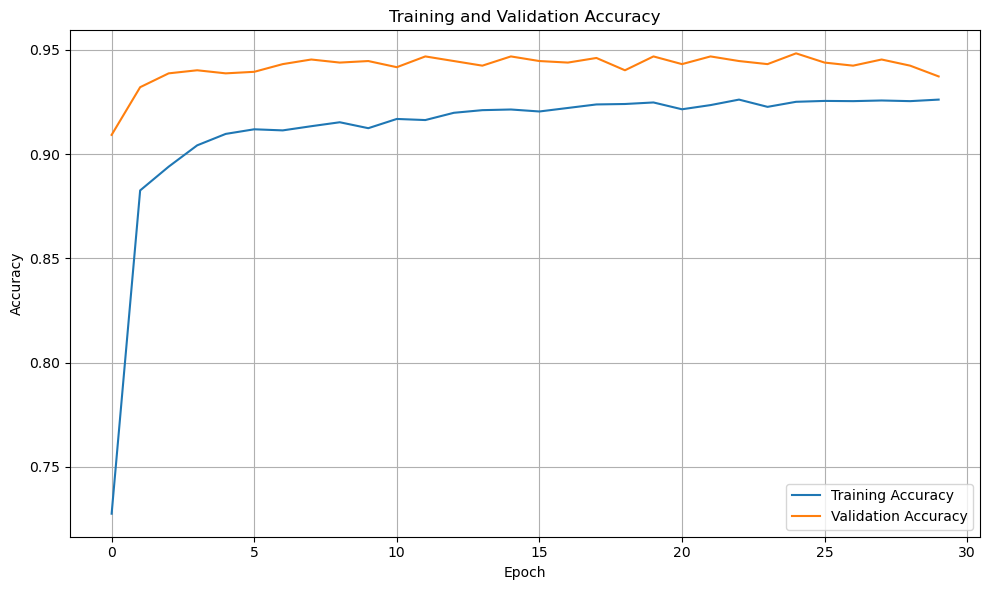

In [58]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Plot training and validation loss

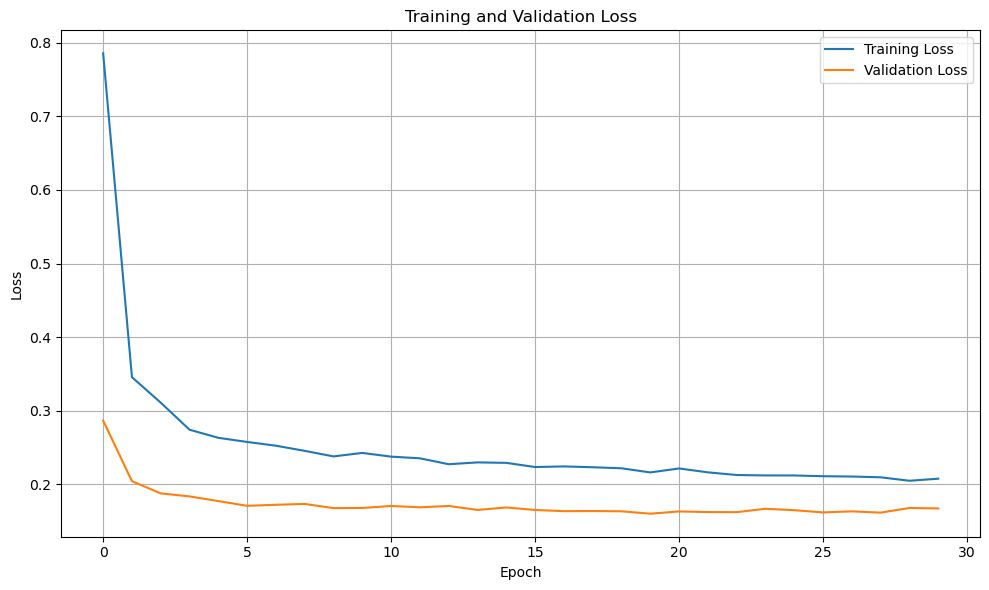

In [59]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Evaluate the model on test data

In [60]:
test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy Percentage: {test_accuracy * 100:.2f}%")

Test Loss: 0.2073
Test Accuracy: 0.9236
Test Accuracy Percentage: 92.36%


In [61]:
prediction_probabilities = model.predict(
    X_test_scaled
)

print(prediction_probabilities[:3])

85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
[[7.0128522e-06 2.6399803e-07 2.5583955e-07 1.1924714e-03 4.5747643e-07
  9.9830902e-01 4.9053761e-04]
 [2.4847138e-08 9.1929730e-10 1.1325622e-08 9.8908854e-01 2.5914671e-04
  4.0279909e-05 1.0612039e-02]
 [1.1406281e-06 6.6474996e-08 6.7311765e-07 9.4211882e-01 6.3444307e-04
  1.3179048e-03 5.5927016e-02]]


Select the class with the highest probability:

In [62]:
y_pred = np.argmax(
    prediction_probabilities,
    axis=1
)

print("Predicted class numbers:")
print(y_pred[:10])

Predicted class numbers:
[5 3 3 4 5 3 3 3 0 3]


# Calculate accuracy

In [63]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Final Test Accuracy: {accuracy:.4f}")
print(f"Final Test Accuracy: {accuracy * 100:.2f}%")

Final Test Accuracy: 0.9236
Final Test Accuracy: 92.36%


# Classification report

In [64]:
report = classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
)

print(report)

              precision    recall  f1-score   support

    BARBUNYA       0.92      0.88      0.90       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.91      0.94      0.93       326
    DERMASON       0.92      0.93      0.92       709
       HOROZ       0.96      0.95      0.96       372
       SEKER       0.94      0.95      0.95       406
        SIRA       0.88      0.87      0.88       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



# Confusion matrix

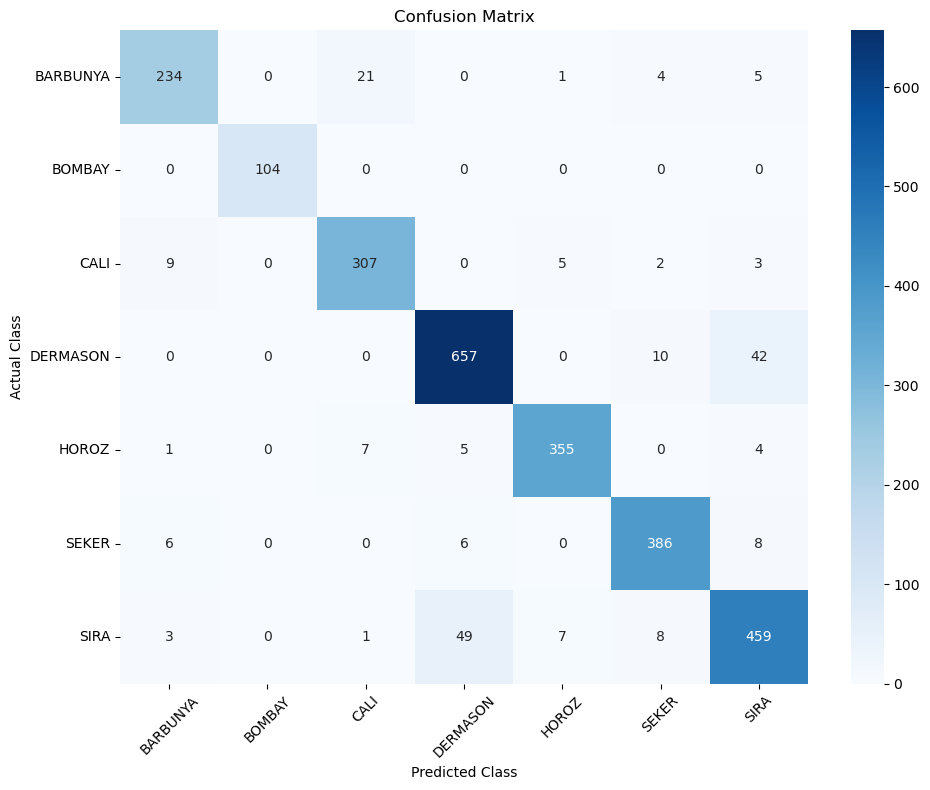

In [65]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Compare actual and predicted results

In [66]:
actual_class_names = label_encoder.inverse_transform(
    y_test
)

predicted_class_names = label_encoder.inverse_transform(
    y_pred
)

results = pd.DataFrame({
    "Actual Class": actual_class_names,
    "Predicted Class": predicted_class_names
})

results["Correct Prediction"] = (
    results["Actual Class"] ==
    results["Predicted Class"]
)

results.head(20)

,Actual Class,Predicted Class,Correct Prediction
0,SEKER,SEKER,True
1,DERMASON,DERMASON,True
2,DERMASON,DERMASON,True
3,HOROZ,HOROZ,True
4,SEKER,SEKER,True
5,DERMASON,DERMASON,True
6,DERMASON,DERMASON,True
7,DERMASON,DERMASON,True
8,BARBUNYA,BARBUNYA,True
9,DERMASON,DERMASON,True


In [78]:
print(
    results["Correct Prediction"]
    .value_counts()
)

Correct Prediction
True     2502
False     207
Name: count, dtype: int64


In [79]:
incorrect_predictions = results[
    results["Correct Prediction"] == False
]

incorrect_predictions.head(20)

,Actual Class,Predicted Class,Correct Prediction
48,SEKER,SIRA,False
51,SEKER,BARBUNYA,False
54,DERMASON,SIRA,False
66,BARBUNYA,CALI,False
68,CALI,HOROZ,False
70,SIRA,DERMASON,False
111,SIRA,SEKER,False
125,DERMASON,SIRA,False
126,BARBUNYA,CALI,False
140,SIRA,DERMASON,False


# Predict one bean from the test set

In [80]:
sample_index = 0

single_sample = X_test_scaled[sample_index].reshape(1, -1)

single_probability = model.predict(
    single_sample,
    verbose=0
)

predicted_number = np.argmax(
    single_probability,
    axis=1
)[0]

predicted_name = label_encoder.inverse_transform(
    [predicted_number]
)[0]

actual_name = label_encoder.inverse_transform(
    [y_test[sample_index]]
)[0]

confidence = np.max(single_probability) * 100

print("Actual bean class:", actual_name)
print("Predicted bean class:", predicted_name)
print(f"Prediction confidence: {confidence:.2f}%")

Actual bean class: SEKER
Predicted bean class: SEKER
Prediction confidence: 99.83%


# Display probabilities for all classes

In [81]:
class_probability_table = pd.DataFrame({
    "Bean Class": label_encoder.classes_,
    "Probability": single_probability[0]
})

class_probability_table["Probability Percentage"] = (
    class_probability_table["Probability"] * 100
)

class_probability_table = class_probability_table.sort_values(
    by="Probability",
    ascending=False
)

print(class_probability_table)

  Bean Class   Probability  Probability Percentage
5      SEKER  9.983090e-01               99.830902
3   DERMASON  1.192470e-03                0.119247
6       SIRA  4.905371e-04                0.049054
0   BARBUNYA  7.012846e-06                0.000701
4      HOROZ  4.574756e-07                0.000046
1     BOMBAY  2.639978e-07                0.000026
2       CALI  2.558393e-07                0.000026


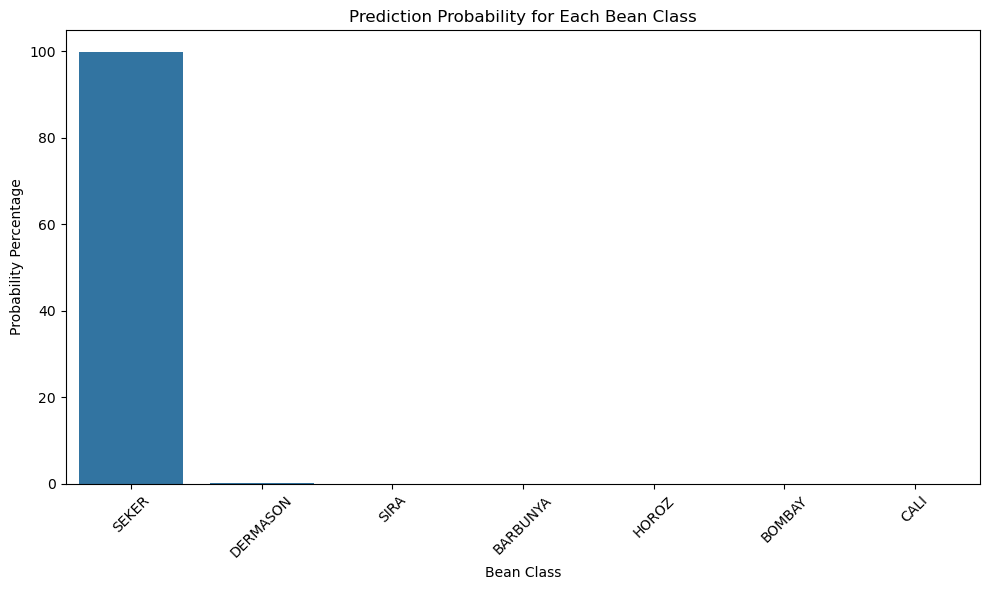

In [82]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=class_probability_table,
    x="Bean Class",
    y="Probability Percentage"
)

plt.title("Prediction Probability for Each Bean Class")
plt.xlabel("Bean Class")
plt.ylabel("Probability Percentage")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Step 27: Predict using manually entered values

In [83]:
sample_values = {
    "Area": 28395,
    "Perimeter": 610.291,
    "MajorAxisLength": 208.178117,
    "MinorAxisLength": 173.888747,
    "AspectRation": 1.197191,
    "Eccentricity": 0.549812,
    "ConvexArea": 28715,
    "EquivDiameter": 190.141097,
    "Extent": 0.763923,
    "Solidity": 0.988856,
    "roundness": 0.958027,
    "Compactness": 0.913358,
    "ShapeFactor1": 0.007332,
    "ShapeFactor2": 0.003147,
    "ShapeFactor3": 0.834222,
    "ShapeFactor4": 0.998724
}

In [84]:
new_bean = pd.DataFrame([sample_values])

new_bean

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724


In [85]:
new_bean_scaled = scaler.transform(new_bean)

In [86]:
new_bean = pd.DataFrame(
    [sample_values],
    columns=X.columns
)

print(new_bean)

    Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0  28395    610.291       208.178117       173.888747      1.197191   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  \
0      0.549812       28715     190.141097  0.763923  0.988856   0.958027   

   Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4  
0     0.913358      0.007332      0.003147      0.834222      0.998724  


In [87]:
new_probability = model.predict(
    new_bean_scaled,
    verbose=0
)

new_class_number = np.argmax(
    new_probability,
    axis=1
)[0]

new_class_name = label_encoder.inverse_transform(
    [new_class_number]
)[0]

new_confidence = np.max(new_probability) * 100

print("Predicted bean class:", new_class_name)
print(f"Confidence: {new_confidence:.2f}%")

Predicted bean class: SEKER
Confidence: 80.69%


# Save the trained model

In [88]:
model.save("dry_bean_ann_model.keras")

# Save the scaler and label encoder

In [89]:
joblib.dump(
    scaler,
    "dry_bean_scaler.pkl"
)

joblib.dump(
    label_encoder,
    "dry_bean_label_encoder.pkl"
)

['dry_bean_label_encoder.pkl']

In [90]:
joblib.dump(
    X.columns.tolist(),
    "dry_bean_feature_names.pkl"
)

['dry_bean_feature_names.pkl']

# Load the saved files

In [91]:
from tensorflow.keras.models import load_model
import joblib

loaded_model = load_model(
    "dry_bean_ann_model.keras"
)

loaded_scaler = joblib.load(
    "dry_bean_scaler.pkl"
)

loaded_label_encoder = joblib.load(
    "dry_bean_label_encoder.pkl"
)

loaded_feature_names = joblib.load(
    "dry_bean_feature_names.pkl"
)

In [92]:
loaded_probability = loaded_model.predict(
    X_test_scaled[:1],
    verbose=0
)

loaded_class_number = np.argmax(
    loaded_probability,
    axis=1
)[0]

loaded_class_name = loaded_label_encoder.inverse_transform(
    [loaded_class_number]
)[0]

print("Prediction from loaded model:", loaded_class_name)

Prediction from loaded model: SEKER
